In [25]:
# In this notebook I will work with the 2021 UK Census data from the ONS
# I will read in the census dataset as well as the variable codes and try to get some insights


import os                       
import glob                     
import numpy as np             
import pandas as pd
import nltk
import string 
import re   
import matplotlib.pyplot as plt 
import seaborn as sns   
%matplotlib inline

In [26]:
os.chdir("/Users/Mark/Documents/Pandas Data/2021 ONS Census")

In [27]:
pwd

'/Users/Mark/Documents/Pandas Data/2021 ONS Census'

In [28]:
ls

Census_2021.csv             Microdata_sample_codes.ods
Census_2021.parquet


In [29]:
with open('Census_2021.csv', 'r') as f:
    # Read just the first few lines to understand the delimiter
    for i in range(5):
        raw_line = f.readline()
        print(f"Line {i}: {repr(raw_line)}")

Line 0: 'resident_id_m,approx_social_grade,country_of_birth_3a,economic_activity_status_10m,ethnic_group_tb_6a,health_in_general,hh_families_type_6a,hours_per_week_worked,in_full_time_education,industry_10a,iol22cd,legal_partnership_status_6a,occupation_10a,region,religion_tb,residence_type,resident_age_7d,sex,usual_short_student\n'
Line 1: 'PTS000000588097,4,1,1,4,1,4,4,2,4,-8,1,5,E12000003,2,1,4,2,1\n'
Line 2: 'PTS000000000320,-8,1,5,4,2,1,-8,2,7,-8,1,2,E12000005,2,1,7,2,1\n'
Line 3: 'PTS000000397448,-8,2,5,4,2,1,-8,2,7,-8,1,3,E12000002,2,1,7,2,1\n'
Line 4: 'PTS000000082442,-8,1,5,4,3,2,-8,2,8,-8,2,8,E12000006,2,1,7,1,1\n'


In [30]:
df = pd.read_csv('Census_2021.csv', delimiter=',')

# Converting to .parquet format to compress the file size
df.to_parquet('Census_2021.parquet', engine='pyarrow', compression='snappy')

# Learning the contents of the census
print(df.columns.tolist())

# First look at the data
df

['resident_id_m', 'approx_social_grade', 'country_of_birth_3a', 'economic_activity_status_10m', 'ethnic_group_tb_6a', 'health_in_general', 'hh_families_type_6a', 'hours_per_week_worked', 'in_full_time_education', 'industry_10a', 'iol22cd', 'legal_partnership_status_6a', 'occupation_10a', 'region', 'religion_tb', 'residence_type', 'resident_age_7d', 'sex', 'usual_short_student']


,resident_id_m,approx_social_grade,country_of_birth_3a,economic_activity_status_10m,ethnic_group_tb_6a,health_in_general,hh_families_type_6a,hours_per_week_worked,in_full_time_education,industry_10a,iol22cd,legal_partnership_status_6a,occupation_10a,region,religion_tb,residence_type,resident_age_7d,sex,usual_short_student
0,PTS000000588097,4,1,1,4,1,4,4,2,4,-8,1,5,E12000003,2,1,4,2,1
1,PTS000000000320,-8,1,5,4,2,1,-8,2,7,-8,1,2,E12000005,2,1,7,2,1
2,PTS000000397448,-8,2,5,4,2,1,-8,2,7,-8,1,3,E12000002,2,1,7,2,1
3,PTS000000082442,-8,1,5,4,3,2,-8,2,8,-8,2,8,E12000006,2,1,7,1,1
4,PTS000000016066,4,1,8,4,2,1,-8,2,9,-8,1,9,E12000002,1,1,2,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604346,PTS000000166524,-8,2,6,4,1,-8,-8,1,-8,-8,1,-8,E12000006,9,2,2,2,1
604347,PTS000000246489,2,1,1,4,2,2,3,2,5,-8,2,7,E12000002,2,1,6,1,1
604348,PTS000000177162,-8,1,9,4,2,-8,-8,2,-8,-8,1,-8,E12000001,2,2,6,1,1
604349,PTS000000377217,-8,1,6,4,1,-8,-8,1,7,-8,1,5,E12000001,1,2,2,2,1


In [31]:
import sys
!{sys.executable} -m pip install odfpy

In [32]:
import lxml

In [33]:
ods = pd.ExcelFile('Microdata_sample_codes.ods', engine='odf')
print(ods.sheet_names)

['Samples_variable_list', 'Microdata_sample_codes']


In [34]:
# Loading the sheet with the specifications of each variable, skipping the first few rows
var_names = pd.read_excel(ods, sheet_name='Samples_variable_list', skiprows=4)
var_names

,Microdata_variable_name,Variable_description
0,66_plus_hh,Households with people aged 66 years and over ...
1,accommodation_type,Accommodation type (9 categories)
2,accommodation_type_5a,Accommodation type (6 categories)
3,accommodation_type_7a,Accommodation type (8 categories)
4,activity_last_week,Economic activity status last week (8 categories)
...,...,...
272,workplace_travel,Distance travelled to work (11 categories)
273,workplace_travel_6m,Distance travelled to work (6 categories)
274,year_arrival_uk,Year of arrival in the UK (13 categories)
275,year_arrival_uk_6a,Year of arrival in the UK (6 categories)


In [35]:
# Loading the sheet with the codes for each variable
var_codes = pd.read_excel(ods, sheet_name='Microdata_sample_codes', skiprows=5)
var_codes

,Microdata_variable_name,Classification_mnemonic,Category_code,Category_label,Classification_label,Similar_variable_in_2011,Data_types,Data_length,Public_data,Safeguarded_household_data,Safeguarded_region_data,Safeguarded_la_data,Secure_household_data,Secure_individual_data
0,66_plus_hh,66_plus_hh,-8,Does not apply,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
1,66_plus_hh,66_plus_hh,0,Female: Aged 66 to 74 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
2,66_plus_hh,66_plus_hh,1,Female: Aged 75 to 84 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
3,66_plus_hh,66_plus_hh,2,Female: Aged 85 years and over,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
4,66_plus_hh,66_plus_hh,3,Male: Aged 66 to 74 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,year_of_arrival_in_country,year_of_arrival_in_country,2017,2017,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33336,year_of_arrival_in_country,year_of_arrival_in_country,2018,2018,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33337,year_of_arrival_in_country,year_of_arrival_in_country,2019,2019,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33338,year_of_arrival_in_country,year_of_arrival_in_country,2020,2020,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes


In [36]:
# Some basic information about the census data

print(f'The dimension of the dataset are: {df.shape}')
print(f'\nThe data types in the dataset are: \n{df.dtypes}')

# Learning unique codes for a variable like 'region'
df['region'].unique()

The dimension of the dataset are: (604351, 19)

The data types in the dataset are: 
resident_id_m                   object
approx_social_grade              int64
country_of_birth_3a              int64
economic_activity_status_10m     int64
ethnic_group_tb_6a               int64
health_in_general                int64
hh_families_type_6a              int64
hours_per_week_worked            int64
in_full_time_education           int64
industry_10a                     int64
iol22cd                         object
legal_partnership_status_6a      int64
occupation_10a                   int64
region                          object
religion_tb                      int64
residence_type                   int64
resident_age_7d                  int64
sex                              int64
usual_short_student              int64
dtype: object


array(['E12000003', 'E12000005', 'E12000002', 'E12000006', 'E12000007',
       'E12000008', 'E12000001', 'E12000004', 'E12000009', 'W92000004'],
      dtype=object)

In [37]:
# Checking for missing values

df.isna().sum()

resident_id_m                   0
approx_social_grade             0
country_of_birth_3a             0
economic_activity_status_10m    0
ethnic_group_tb_6a              0
health_in_general               0
hh_families_type_6a             0
hours_per_week_worked           0
in_full_time_education          0
industry_10a                    0
iol22cd                         0
legal_partnership_status_6a     0
occupation_10a                  0
region                          0
religion_tb                     0
residence_type                  0
resident_age_7d                 0
sex                             0
usual_short_student             0
dtype: int64

In [38]:
# A quick look at the data informs us that there ARE indeed missing values, but they are coded as -8 instead of 'N/A'
# We thus need to transform the values - easy for numerical series, trickier for an 'object' column like iol22cd

# Transforming '-8's in iol22cd into floats to work out N/As:

def convert_numerics_only(series):
    """
    Converts numeric strings in a Series to actual numbers 
    while preserving non-numeric text.
    """
    numeric_series = pd.to_numeric(series, errors='coerce')
    return numeric_series.fillna(series)

df['iol22cd'] = convert_numerics_only(df['iol22cd'])
df = df.replace(-8, np.nan)   # Replacing the values of -8 in the dataset with actual N/As

In [39]:
df.sample(30)

,resident_id_m,approx_social_grade,country_of_birth_3a,economic_activity_status_10m,ethnic_group_tb_6a,health_in_general,hh_families_type_6a,hours_per_week_worked,in_full_time_education,industry_10a,iol22cd,legal_partnership_status_6a,occupation_10a,region,religion_tb,residence_type,resident_age_7d,sex,usual_short_student
506052,PTS000000363574,2.0,1.0,5.0,4.0,2.0,2.0,NaN,2.0,8.0,NaN,2.0,4.0,E12000003,2.0,1,7,1,1
483681,PTS000000570388,3.0,1.0,NaN,2.0,1.0,2.0,NaN,NaN,NaN,E13000002,NaN,NaN,E12000007,2.0,1,1,2,1
188342,PTS000000243424,4.0,1.0,1.0,4.0,2.0,2.0,2.0,2.0,7.0,NaN,2.0,8.0,E12000005,1.0,1,5,2,1
484244,PTS000000011024,2.0,1.0,9.0,4.0,1.0,3.0,NaN,2.0,4.0,NaN,1.0,9.0,E12000002,2.0,1,2,2,1
332184,PTS000000117588,1.0,1.0,5.0,4.0,2.0,2.0,NaN,2.0,5.0,NaN,2.0,7.0,E12000003,2.0,1,7,1,1
380020,PTS000000334811,4.0,1.0,8.0,4.0,4.0,2.0,NaN,2.0,8.0,NaN,2.0,6.0,W92000004,2.0,1,6,2,1
127881,PTS000000303741,2.0,1.0,NaN,4.0,2.0,4.0,NaN,1.0,NaN,NaN,NaN,NaN,E12000003,2.0,1,1,2,1
484406,PTS000000196211,4.0,1.0,8.0,4.0,3.0,1.0,NaN,2.0,NaN,E13000001,1.0,NaN,E12000007,2.0,1,6,1,1
58863,PTS000000257081,NaN,1.0,5.0,4.0,2.0,2.0,NaN,2.0,NaN,NaN,2.0,NaN,E12000008,2.0,1,7,1,1
258924,PTS000000494752,3.0,2.0,1.0,5.0,1.0,2.0,3.0,2.0,5.0,E13000001,2.0,5.0,E12000007,6.0,1,5,2,1


In [40]:
df.isna().sum()
# Now the data contains N/As as needed

resident_id_m                        0
approx_social_grade             130202
country_of_birth_3a               6989
economic_activity_status_10m    117116
ethnic_group_tb_6a                6989
health_in_general                 6989
hh_families_type_6a              11289
hours_per_week_worked           326132
in_full_time_education           32203
industry_10a                    171052
iol22cd                         514862
legal_partnership_status_6a     111272
occupation_10a                  171052
region                               0
religion_tb                       6989
residence_type                       0
resident_age_7d                      0
sex                                  0
usual_short_student                  0
dtype: int64

In [41]:
# Checking the frequency of unique values for the 'region' variable - but meaning remains shrouded behind the codes
print(df['region'].value_counts())

region
E12000008    94344
E12000007    89489
E12000002    75080
E12000006    64258
E12000005    60231
E12000009    57815
E12000003    55469
E12000004    49440
W92000004    31458
E12000001    26767
Name: count, dtype: int64


In [42]:
var_codes

,Microdata_variable_name,Classification_mnemonic,Category_code,Category_label,Classification_label,Similar_variable_in_2011,Data_types,Data_length,Public_data,Safeguarded_household_data,Safeguarded_region_data,Safeguarded_la_data,Secure_household_data,Secure_individual_data
0,66_plus_hh,66_plus_hh,-8,Does not apply,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
1,66_plus_hh,66_plus_hh,0,Female: Aged 66 to 74 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
2,66_plus_hh,66_plus_hh,1,Female: Aged 75 to 84 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
3,66_plus_hh,66_plus_hh,2,Female: Aged 85 years and over,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
4,66_plus_hh,66_plus_hh,3,Male: Aged 66 to 74 years,Households with people aged 66 years and over ...,PENHUK11,int,2,no,no,yes,no,yes,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33335,year_of_arrival_in_country,year_of_arrival_in_country,2017,2017,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33336,year_of_arrival_in_country,year_of_arrival_in_country,2018,2018,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33337,year_of_arrival_in_country,year_of_arrival_in_country,2019,2019,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes
33338,year_of_arrival_in_country,year_of_arrival_in_country,2020,2020,Year of arrival in UK (117 categories),YRARR_YEAR,smallint,9,no,no,no,no,yes,yes


In [43]:
# We only need three columns for the present analysis
var_codes = var_codes[['Microdata_variable_name', 'Category_code', 'Category_label']]

In [44]:
# An example for one of the variables
var_codes[var_codes['Microdata_variable_name']=='year_of_arrival_in_country']

,Microdata_variable_name,Category_code,Category_label
33223,year_of_arrival_in_country,-8,Does not apply
33224,year_of_arrival_in_country,1906,1906
33225,year_of_arrival_in_country,1907,1907
33226,year_of_arrival_in_country,1908,1908
33227,year_of_arrival_in_country,1909,1909
...,...,...,...
33335,year_of_arrival_in_country,2017,2017
33336,year_of_arrival_in_country,2018,2018
33337,year_of_arrival_in_country,2019,2019
33338,year_of_arrival_in_country,2020,2020


In [45]:
# A function for transforming the 'codes' dataframe into a small dataframe with only one variable, its codes and 'labels', i.e. intelligible values
# It then performs a merger of this new dataframe and the original census, returning the census with a new column for the 'labels' of a particular variable

def merger_on_a_variable(df, var_codes, variable):
    if variable in df.columns:
        new_series = var_codes[var_codes['Microdata_variable_name']==variable].drop(columns='Microdata_variable_name')
        new_series = new_series.rename(columns={'Category_code': variable})
        new_df = pd.merge(
        df,
        new_series,
        on=variable,
        how='left')
        return new_df.rename(columns={'Category_label': f'{variable}_label'})
    return df

In [46]:
# I've chosen four variables of interest to perform the merger

variables_to_explore = ['region', 'country_of_birth_3a', 'ethnic_group_tb_6a', 'religion_tb']
for var in variables_to_explore:
    df = merger_on_a_variable(df, var_codes, var)

# Checking the existence of new 'descriptive' columns
df[['resident_id_m', 'region_label', 'country_of_birth_3a_label', 'ethnic_group_tb_6a_label', 'religion_tb_label']]

,resident_id_m,region_label,country_of_birth_3a_label,ethnic_group_tb_6a_label,religion_tb_label
0,PTS000000588097,Yorkshire and The Humber,Born in the UK,White,Christian
1,PTS000000000320,West Midlands,Born in the UK,White,Christian
2,PTS000000397448,North West,Born outside the UK,White,Christian
3,PTS000000082442,East of England,Born in the UK,White,Christian
4,PTS000000016066,North West,Born in the UK,White,No religion
...,...,...,...,...,...
604346,PTS000000166524,East of England,Born outside the UK,White,Not answered
604347,PTS000000246489,North West,Born in the UK,White,Christian
604348,PTS000000177162,North East,Born in the UK,White,Christian
604349,PTS000000377217,North East,Born in the UK,White,No religion


Text(0, 0.5, 'Number of resident respondents')

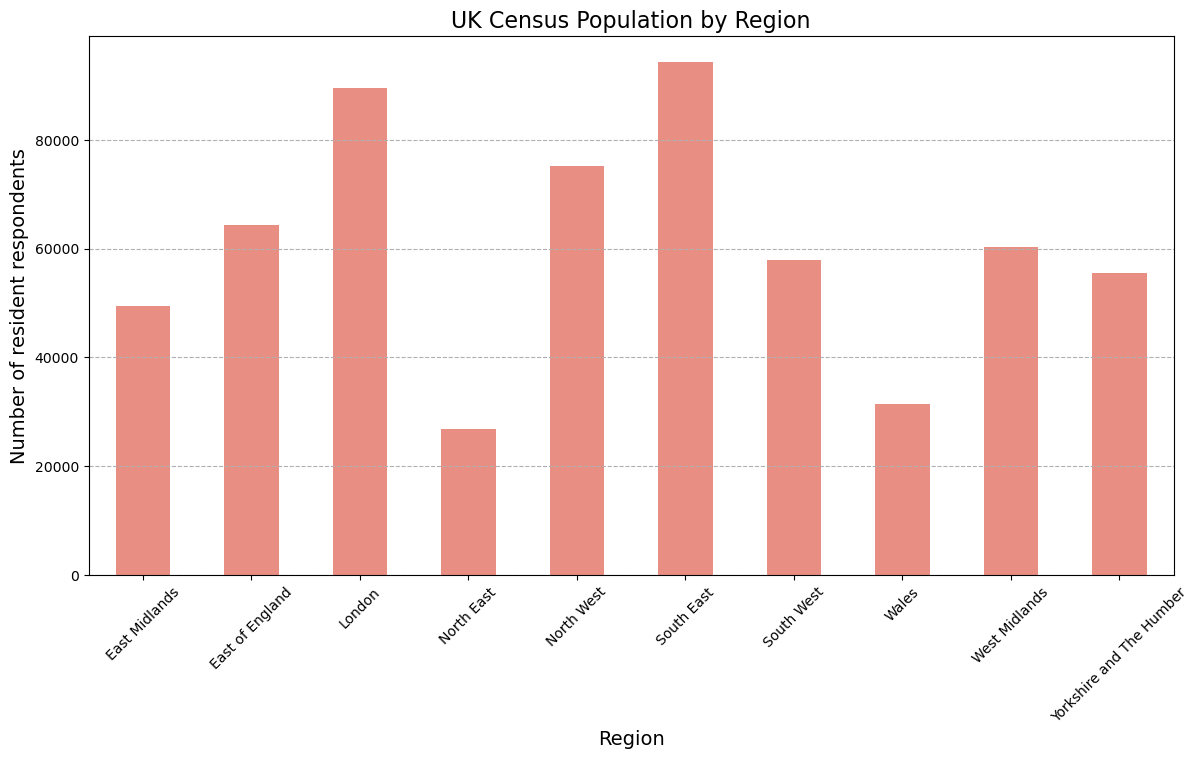

In [47]:
# Seems to work

# Count how many respondents belong to each region
region_count = df['region_label'].value_counts().sort_index()

# Plot an illustrative bar chart
plt.figure(figsize=(14,7))
sns.barplot(x=region_count.index.astype(str), y=region_count.values, color='salmon', width=0.5)
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45, fontsize=10)

plt.title('UK Census Population by Region', fontsize=16)
plt.xlabel('Region', fontsize=14)
plt.ylabel('Number of resident respondents', fontsize=14)



Text(0, 0.5, 'Number of respondents')

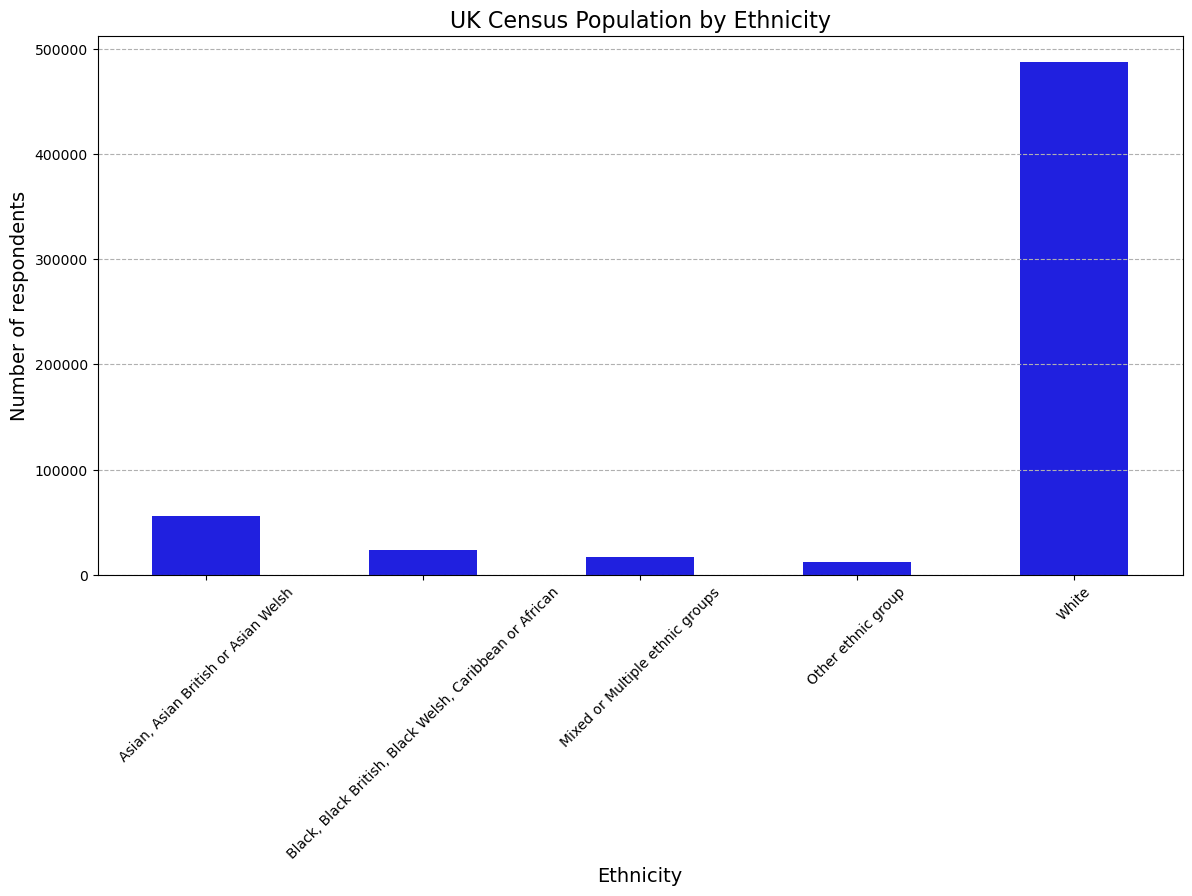

In [48]:
# Count how respondents identify ethnically
ethnicity_count = df['ethnic_group_tb_6a_label'].value_counts().sort_index()

# Plot an illustrative bar chart
plt.figure(figsize=(14,7))
sns.barplot(x=ethnicity_count.index.astype(str), y=ethnicity_count.values, color='blue', width=0.5)
plt.grid(axis='y', linestyle='--')
plt.xticks(rotation=45, fontsize=10)

plt.title('UK Census Population by Ethnicity', fontsize=16)
plt.xlabel('Ethnicity', fontsize=14)
plt.ylabel('Number of respondents', fontsize=14)